<a href="https://colab.research.google.com/github/Greeshma-babu/AI_Projects/blob/main/Stock_Market_Analysis_Prediction_using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install numpy pandas matplotlib scikit-learn torch

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler is a preprocessing technique used in ML to scale
# numerical data to a fixed range, usually 0 to 1.


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Stock_Price_Dataset.csv to Stock_Price_Dataset.csv


In [4]:
df = pd.read_csv("Stock_Price_Dataset.csv")
df

,Date,AMZN,DPZ,BTC,NFLX
0,5/1/2013,248.229996,51.190983,106.250000,30.415714
1,5/2/2013,252.550003,51.987320,98.099998,30.641428
2,5/3/2013,258.049988,52.446388,112.900002,30.492857
3,5/6/2013,255.720001,53.205257,109.599998,30.098572
4,5/7/2013,257.730011,54.151505,113.199997,29.464285
...,...,...,...,...,...
1515,5/8/2019,1917.770020,283.149994,6171.959961,364.369995
1516,5/9/2019,1899.869995,282.160004,6358.290039,362.750000
1517,5/10/2019,1889.979980,278.369995,7191.359863,361.040009
1518,5/13/2019,1822.680054,273.880005,7980.129883,345.260010


In [5]:
df = df.drop(columns=['AMZN', 'DPZ', 'BTC'])

In [6]:
df.rename(columns={'NFLX': 'Stock_price'}, inplace=True)

In [7]:
print(df)

           Date  Stock_price
0      5/1/2013    30.415714
1      5/2/2013    30.641428
2      5/3/2013    30.492857
3      5/6/2013    30.098572
4      5/7/2013    29.464285
...         ...          ...
1515   5/8/2019   364.369995
1516   5/9/2019   362.750000
1517  5/10/2019   361.040009
1518  5/13/2019   345.260010
1519  5/14/2019   345.609985

[1520 rows x 2 columns]


**Preprocessing - Normalization**

In [16]:
data = df['Stock_price'].values.reshape(-1,1)

# reshape(-1, 1) is a NumPy function that changes the shape of an array
# 1 -> I want exactly 1 column
# -1 ->  You calculate this dimension automatically -You don't tell NumPy how many rows you want.
# It figures it out based on: the total number of elements, and the other dimension you specified.

# MinMaxScaler expects a 2D array with the shape. Converts 1D to 2D
data

array([[ 30.415714],
       [ 30.641428],
       [ 30.492857],
       ...,
       [361.040009],
       [345.26001 ],
       [345.609985]])

In [17]:
# Normalize the value uisng MinMaxScaler - 0 t0 1
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
data_scaled

array([[0.00244266],
       [0.00302215],
       [0.00264071],
       ...,
       [0.85127306],
       [0.81076018],
       [0.81165869]])

**Create Sequence (Sliding Window)**

In [18]:
"""
Parameters:
* data → Your stock prices (already scaled)
* seq_len=60 → Use the previous 60 days to predict the next day.
For example : [1, 2, 3, 4 , 5] seq_len = 2
              x[] -> [1, 2] y[] -> 3
"""
def create_sequence(data, seq_len = 60):
  x,y = [],[]
  for i in range(len(data)- seq_len): # Other wise error, Try to access last index + 60 -> IndexOutOfBound error
    x.append(data[i:i+seq_len]) # first loop - 0 to 61 value
    y.append(data[i+ seq_len]) # value 61
  return np.array(x),np.array(y)

In [11]:
x, y = create_sequence(data_scaled, seq_len = 50)
print("Input shape:", x.shape) # (number of samples, time steps, number of features)
print("Ouput shape:", y.shape) # (number of samples, number of features)

Input shape: (1470, 50, 1)
Ouput shape: (1470, 1)


**Train Test Split**

In [19]:
train_size = int(len(x) * 0.8 )
print("train_size = ", train_size)

# From the total data, take 80 % for training and remianing 20 % for validation.
# In NN, we need to convert to tensor
x_train = torch.tensor(x[:train_size], dtype=torch.float32)
y_train = torch.tensor(y[:train_size], dtype=torch.float32)
x_test = torch.tensor(x[train_size:], dtype=torch.float32)
y_test = torch.tensor(y[train_size:], dtype=torch.float32)

print("x = ",x.shape)
print("y = ",y.shape)
print("x_train = ", x_train.shape)
print("y_train = ", y_train.shape)
print("x_test = ", x_test.shape)
print("y_test = ", y_test.shape)

train_size =  1176
x =  (1470, 50, 1)
y =  (1470, 1)
x_train =  torch.Size([1176, 50, 1])
y_train =  torch.Size([1176, 1])
x_test =  torch.Size([294, 50, 1])
y_test =  torch.Size([294, 1])


**Build LSTM (Long Short Term Memory) Model**

In [20]:
"""
nn.Module → PyTorch's base class for all neural networks

By inheriting from nn.Module, your model gets PyTorch features like:
storing layers, training, saving weights, using optimizers


input_size : How many values enter the LSTM at each time step
hidden_size : It converts information into a hidden representation. The number of memory units inside the LSTM.
num_layers : Number of LSTM layers stacked on top of each other.
Input-> LSTM layer 1 -> LSTM layer 2 ->LSTM layer 3 -> Predict Output
More layers allow learning more complex patterns.

super().__init__() : This class is a neural network.
Please prepare it for managing layers and parameters.

batch_first : This tells PyTorch your input format is: (batch_size, sequence_length, input_size)
This is easier because most PyTorch data loaders produce batches first.

nn.Linear(hidden_size, 1) : 128 value -> Linear -> 1 value
out,_ = self.lstm(x)  : (1470,50,1) -> (1470,50,128)
1470 samples, 50 days, 128 learned features

__init__() → What layers exist?
forward() → How does data move through those layers?
forward() tells the order in which machines are used.

"""

class LSTMModel(nn.Module):

  def __init__(self, input_size=1, hidden_size=128, num_layers=3):
    super().__init__()
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True) # Create LSTM Layer
    self.fc = nn.Linear(hidden_size, 1) # final prediction layer

  def forward(self, x): # forward defines how data moves through your model.
      out,_ = self.lstm(x) # Pass data through LSTM
      out = out[:,-1,:] # Take last time step
      out = self.fc(out) # Prediction Layer : (1470,128) -> (1470,1)
      return out
model = LSTMModel()
model

LSTMModel(
  (lstm): LSTM(1, 128, num_layers=3, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

**Define Loss and Optimizer - Adam Optimizer**

In [21]:
"""
Loss : How wrong is your prediction compared to the actual value?
MSE = Mean Squared Error
optimizer updates the model's weights so that the loss decreases.
Adam = Adaptive Moment Estimation.
How much should I change each weight to improve the model?
Use Adam to adjust LSTM weights slowly so predictions become more accurate.
"""

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0005)

**Training Loop**

In [22]:
epochs = 200
for epoch in range(epochs):
  model.train()
  output = model(x_train) # predict output
  loss = criterion(output, y_train) # Calculate loss
  loss.backward() # Backward propagation
  optimizer.step() # Update weight
  print(f"Epoch: [{epoch+1}/{epochs}], loss = {loss.item(): .4f}")

Epoch: [1/200], loss =  0.0836
Epoch: [2/200], loss =  0.0719
Epoch: [3/200], loss =  0.0617
Epoch: [4/200], loss =  0.0525
Epoch: [5/200], loss =  0.0443
Epoch: [6/200], loss =  0.0369
Epoch: [7/200], loss =  0.0306
Epoch: [8/200], loss =  0.0253
Epoch: [9/200], loss =  0.0214
Epoch: [10/200], loss =  0.0195
Epoch: [11/200], loss =  0.0203
Epoch: [12/200], loss =  0.0248
Epoch: [13/200], loss =  0.0343
Epoch: [14/200], loss =  0.0484
Epoch: [15/200], loss =  0.0626
Epoch: [16/200], loss =  0.0703
Epoch: [17/200], loss =  0.0690
Epoch: [18/200], loss =  0.0613
Epoch: [19/200], loss =  0.0508
Epoch: [20/200], loss =  0.0405
Epoch: [21/200], loss =  0.0320
Epoch: [22/200], loss =  0.0259
Epoch: [23/200], loss =  0.0221
Epoch: [24/200], loss =  0.0202
Epoch: [25/200], loss =  0.0198
Epoch: [26/200], loss =  0.0206
Epoch: [27/200], loss =  0.0221
Epoch: [28/200], loss =  0.0242
Epoch: [29/200], loss =  0.0265
Epoch: [30/200], loss =  0.0290
Epoch: [31/200], loss =  0.0315
Epoch: [32/200], 

**Predictions**

In [23]:
model.eval()
with torch.no_grad():
  train_pred = model(x_train).numpy() # predict training data
  test_pred = model(x_test).numpy() # predict test data
  print("train_pred =", train_pred)
  print("test_pred =", test_pred)

train_pred = [[0.16135977]
 [0.16259529]
 [0.16492888]
 ...
 [0.13674296]
 [0.14294371]
 [0.16151862]]
test_pred = [[0.15510285]
 [0.12368143]
 [0.14538516]
 [0.1794962 ]
 [0.13822797]
 [0.12246332]
 [0.16445285]
 [0.16950177]
 [0.1251508 ]
 [0.13245264]
 [0.18017915]
 [0.16091429]
 [0.10353541]
 [0.14933744]
 [0.20749107]
 [0.12563214]
 [0.123106  ]
 [0.19232759]
 [0.15762362]
 [0.11591577]
 [0.15941429]
 [0.18825877]
 [0.13015558]
 [0.1285021 ]
 [0.17338404]
 [0.16357884]
 [0.14130393]
 [0.13081115]
 [0.14486133]
 [0.16101113]
 [0.14015001]
 [0.13661264]
 [0.16404372]
 [0.15944165]
 [0.12937587]
 [0.14504704]
 [0.16918153]
 [0.14394811]
 [0.13661408]
 [0.16336267]
 [0.15482932]
 [0.13158497]
 [0.14844434]
 [0.1603752 ]
 [0.1402959 ]
 [0.14189486]
 [0.15567169]
 [0.14827932]
 [0.14028372]
 [0.15194276]
 [0.1583148 ]
 [0.14304271]
 [0.1462807 ]
 [0.15217859]
 [0.14061406]
 [0.14446169]
 [0.15431887]
 [0.14627165]
 [0.1434547 ]
 [0.1481134 ]
 [0.14616542]
 [0.14152783]
 [0.14186396]
 [0

**Inverse Scaling**

In [29]:
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_train_actual = scaler.inverse_transform(y_train.numpy())
y_test_actual = scaler.inverse_transform(y_test.numpy())

print("y_train_actual =", y_train_actual)
print("y_test_actual =", y_test_actual)

y_train_actual = [[ 36.751427]
 [ 36.854286]
 [ 37.21143 ]
 ...
 [331.44    ]
 [321.3     ]
 [315.88    ]]
y_test_actual = [[321.55   ]
 [321.09   ]
 [318.45   ]
 [313.48   ]
 [317.5    ]
 [316.48   ]
 [306.7    ]
 [300.94   ]
 [320.35   ]
 [300.69   ]
 [285.77   ]
 [295.35   ]
 [280.29   ]
 [283.67   ]
 [288.94   ]
 [293.97   ]
 [288.85   ]
 [289.93   ]
 [298.07   ]
 [303.67   ]
 [309.25   ]
 [311.65   ]
 [307.78   ]
 [336.06   ]
 [334.52   ]
 [332.7    ]
 [327.77   ]
 [318.69   ]
 [307.02   ]
 [305.76   ]
 [313.98   ]
 [311.76   ]
 [312.46   ]
 [313.3    ]
 [313.36   ]
 [311.69   ]
 [320.09   ]
 [326.26   ]
 [326.89   ]
 [330.3    ]
 [329.6    ]
 [326.46   ]
 [328.53   ]
 [326.13   ]
 [328.19   ]
 [325.22   ]
 [324.18   ]
 [331.82   ]
 [331.62   ]
 [344.72   ]
 [349.29   ]
 [351.29   ]
 [349.73   ]
 [353.54   ]
 [351.6    ]
 [359.93   ]
 [361.81   ]
 [365.8    ]
 [367.45   ]
 [361.4    ]
 [360.57   ]
 [361.45   ]
 [363.83   ]
 [379.93   ]
 [392.87   ]
 [391.98   ]
 [390.39996]
 [404.

**Visualization**

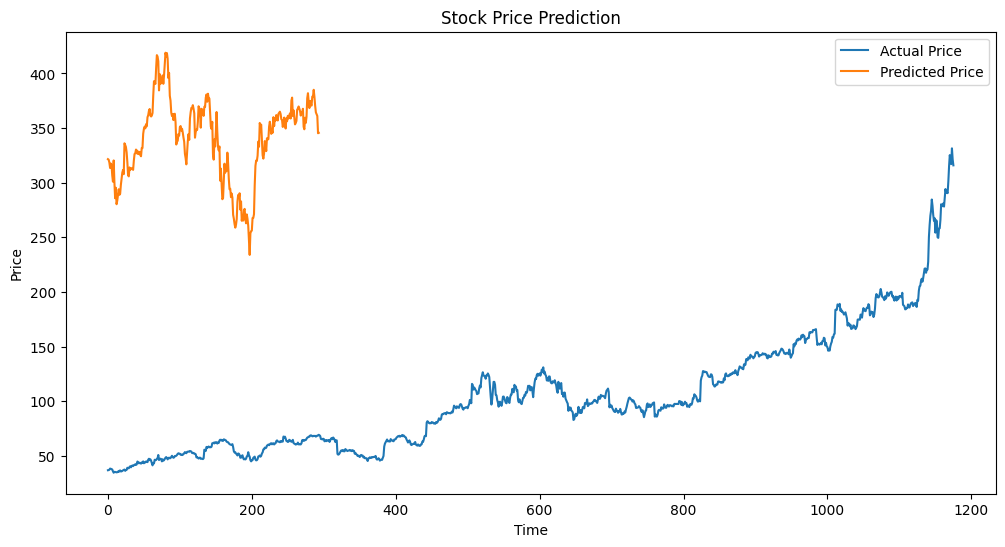

In [31]:
plt.figure(figsize = (12,6))
plt.plot(y_train_actual, label = "Actual Price")
plt.plot(y_test_actual, label = "Predicted Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Stock Price Prediction")
plt.legend() # small box (legend) that tells you which line represents what.
plt.show()